In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import os
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [44]:
print(pd.read_csv('/content/Europe_crisis.csv').info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4557 entries, 0 to 4556
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4557 non-null   int64  
 1   CC3                       4557 non-null   object 
 2   Country                   4557 non-null   object 
 3   Year                      4557 non-null   float64
 4   Banking Crisis            4081 non-null   float64
 5   Systemic Crisis           4545 non-null   float64
 6   exch_usd                  3732 non-null   object 
 7   National Currency         4122 non-null   object 
 8   exch_sources              4556 non-null   object 
 9   Domestic Debt             3896 non-null   float64
 10  Sovereign External debt1  3905 non-null   object 
 11  Sovereign External debt2  3905 non-null   float64
 12  GDP_Weighted_default      3903 non-null   float64
 13  Inflation                 3647 non-null   object 
 14  Independ

In [45]:
countries = pd.read_csv('Europe_crisis.csv')['Country'].dropna().unique()
print(f"Количество стран: {len(countries)}\nСписок: {', '.join(countries)}")

Количество стран: 21
Список: Austria, Belgium, Denmark, Finland, France, Germany, Greece, Hungary, Iceland, Ireland, Italy, Netherlands, Norway, Poland, Portugal, Romania, Russia, Spain, Sweden, Switzerland, United Kingdom


In [46]:
import pandas as pd

df = pd.read_csv('Europe_crisis.csv')
df.columns = df.columns.str.strip()
crises = df[(df['Banking Crisis'] == 1) | (df['Systemic Crisis'] == 1)]
print(crises[['Country', 'Year']].to_string(index=False))

       Country   Year
       Austria 1873.0
       Austria 1874.0
       Austria 1924.0
       Austria 1929.0
       Austria 1931.0
       Austria 1932.0
       Austria 1933.0
       Austria 2008.0
       Austria 2009.0
       Austria 2010.0
       Austria 2011.0
       Belgium 1838.0
       Belgium 1839.0
       Belgium 1842.0
       Belgium 1848.0
       Belgium 1849.0
       Belgium 1870.0
       Belgium 1871.0
       Belgium 1914.0
       Belgium 1925.0
       Belgium 1926.0
       Belgium 1931.0
       Belgium 1934.0
       Belgium 1935.0
       Belgium 1939.0
       Belgium 2008.0
       Belgium 2009.0
       Belgium 2010.0
       Belgium 2011.0
       Belgium 2012.0
       Belgium 2013.0
       Belgium 2014.0
       Denmark 1813.0
       Denmark 1857.0
       Denmark 1877.0
       Denmark 1885.0
       Denmark 1902.0
       Denmark 1907.0
       Denmark 1914.0
       Denmark 1921.0
       Denmark 1931.0
       Denmark 1987.0
       Denmark 1988.0
       Denmark 1989.0
       Den

In [47]:
#
df = pd.read_csv('Europe_crisis.csv')
last_year = df['Year'].max()
print(f"Последний год в данных: {last_year}")

Последний год в данных: 2016.0


In [48]:
# Шаг 1: Проверяем файл
file_name = "Europe_crisis.csv"

if not os.path.exists(file_name):
    print(f"❌ Файл '{file_name}' не найден!")
    print("Убедитесь, что файл находится в той же папке, что и скрипт.")
    exit(1)

print(f"✅ Файл найден: {file_name}")
print(f"Размер файла: {os.path.getsize(file_name)} байт")

# Шаг 2: Пытаемся прочитать файл разными способами
print("\n" + "=" * 60)
print("ПОПЫТКА ЧТЕНИЯ ФАЙЛА")
print("=" * 60)

try:
    # Способ 1: Стандартное чтение
    print("Способ 1: pd.read_csv()...")
    df = pd.read_csv(file_name, encoding='utf-8')
    print(f"✅ Успешно! Строк: {len(df)}, Столбцов: {len(df.columns)}")

except Exception as e1:
    print(f"❌ Ошибка: {e1}")

    try:
        # Способ 2: Чтение с указанием разделителя
        print("\nСпособ 2: Чтение с engine='python'...")
        df = pd.read_csv(file_name, engine='python', encoding='utf-8')
        print(f"✅ Успешно! Строк: {len(df)}, Столбцов: {len(df.columns)}")

    except Exception as e2:
        print(f"❌ Ошибка: {e2}")

        try:
            # Способ 3: Чтение построчно
            print("\nСпособ 3: Ручное чтение...")
            with open(file_name, 'r', encoding='utf-8') as f:
                lines = f.readlines()

            # Находим строку с заголовками
            for i, line in enumerate(lines):
                if 'CC3,Country,Year,Banking Crisis' in line:
                    header_line = i
                    break
            else:
                header_line = 0

            # Читаем начиная с заголовка
            df = pd.read_csv(file_name, skiprows=header_line, encoding='utf-8')
            print(f"✅ Успешно! Строк: {len(df)}, Столбцов: {len(df.columns)}")

        except Exception as e3:
            print(f"❌ Все способы не сработали: {e3}")
            exit(1)

# Шаг 3: Показываем информацию о данных
print("\n" + "=" * 60)
print("ИНФОРМАЦИЯ О ДАННЫХ")
print("=" * 60)

print(f"Всего строк: {len(df)}")
print(f"Всего столбцов: {len(df.columns)}")
print("\nСтолбцы:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

# Шаг 4: Исправляем основные проблемы
print("\n" + "=" * 60)
print("ИСПРАВЛЕНИЕ ПРОБЛЕМ")
print("=" * 60)

# 1. Удаляем первый безымянный столбец если есть
if df.columns[0] in ['', 'Unnamed: 0']:
    print("Удаляю безымянный столбец...")
    df = df.iloc[:, 1:]

# 2. Исправляем названия столбцов (убираем пробелы)
df.columns = [col.strip() for col in df.columns]

# 3. Исправляем год
if 'Year' in df.columns:
    print("Исправляю формат года...")
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df['Year'] = df['Year'].fillna(0).astype(int)

# 4. Обрабатываем числовые столбцы
numeric_cols = ['Banking Crisis', 'Systemic Crisis', 'exch_usd',
                'Domestic Debt', 'Sovereign External debt1',
                'Sovereign External debt2', 'GDP_Weighted_default',
                'Inflation', 'Currency Crises', 'Inflation Crises']

for col in numeric_cols:
    if col in df.columns:
        print(f"Обрабатываю {col}...")
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Удаляем полностью пустые строки
initial_rows = len(df)
df = df.dropna(how='all')
removed_rows = initial_rows - len(df)
if removed_rows > 0:
    print(f"Удалено пустых строк: {removed_rows}")

# Шаг 5: Сохраняем очищенный файл
output_file = "Europe_crisis_CLEANED.csv"
print("\n" + "=" * 60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТА")
print("=" * 60)

df.to_csv(output_file, index=False, encoding='utf-8')
print(f"✅ Очищенный файл сохранен как: {output_file}")
print(f"✅ Размер: {len(df)} строк × {len(df.columns)} столбцов")

# Шаг 6: Создаем краткий отчет
report_file = "data_report.txt"
with open(report_file, 'w', encoding='utf-8') as f:
    f.write("ОТЧЕТ ПО ДАННЫМ: Europe_crisis.csv\n")
    f.write("=" * 50 + "\n\n")

    f.write("ОСНОВНАЯ ИНФОРМАЦИЯ:\n")
    f.write(f"- Всего строк: {len(df)}\n")
    f.write(f"- Всего столбцов: {len(df.columns)}\n")
    f.write(f"- Страны: {df['Country'].nunique()}\n")
    f.write(f"- Годы: {df['Year'].min()} - {df['Year'].max()}\n\n")

    f.write("СТАТИСТИКА ПО СТРАНАМ:\n")
    country_counts = df['Country'].value_counts().head(10)
    for country, count in country_counts.items():
        f.write(f"- {country}: {count} записей\n")

    f.write("\nПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:\n")
    missing = df.isnull().sum()
    for col, count in missing.items():
        if count > 0:
            percent = (count / len(df)) * 100
            f.write(f"- {col}: {count} ({percent:.1f}%)\n")

print(f"📊 Отчет сохранен как: {report_file}")

# Шаг 7: Показываем пример данных
print("\n" + "=" * 60)
print("ПРИМЕР ДАННЫХ (первые 5 строк)")
print("=" * 60)
print(df.head().to_string())

print("\n" + "=" * 60)
print("✅ ОЧИСТКА ЗАВЕРШЕНА УСПЕШНО!")
print("=" * 60)

✅ Файл найден: Europe_crisis.csv
Размер файла: 1023593 байт

ПОПЫТКА ЧТЕНИЯ ФАЙЛА
Способ 1: pd.read_csv()...
✅ Успешно! Строк: 4557, Столбцов: 17

ИНФОРМАЦИЯ О ДАННЫХ
Всего строк: 4557
Всего столбцов: 17

Столбцы:
   1. Unnamed: 0
   2. CC3
   3. Country
   4. Year
   5. Banking Crisis 
   6. Systemic Crisis
   7. exch_usd
   8. National Currency
   9. exch_sources
  10. Domestic Debt
  11. Sovereign External debt1
  12. Sovereign External debt2
  13. GDP_Weighted_default
  14. Inflation
  15. Independence
  16. Currency Crises
  17. Inflation Crises

ИСПРАВЛЕНИЕ ПРОБЛЕМ
Удаляю безымянный столбец...
Исправляю формат года...
Обрабатываю Banking Crisis...
Обрабатываю Systemic Crisis...
Обрабатываю exch_usd...
Обрабатываю Domestic Debt...
Обрабатываю Sovereign External debt1...
Обрабатываю Sovereign External debt2...
Обрабатываю GDP_Weighted_default...
Обрабатываю Inflation...
Обрабатываю Currency Crises...
Обрабатываю Inflation Crises...

СОХРАНЕНИЕ РЕЗУЛЬТАТА
✅ Очищенный файл сохранен к

=== АНАЛИЗ ЭКОНОМИЧЕСКИХ КРИЗИСОВ ===

1. КОЛИЧЕСТВО КРИЗИСОВ ПО СТРАНАМ:
Country
United Kingdom    35
Spain             30
Italy             26
France            26
Netherlands       23
Sweden            22
Denmark           22
Belgium           21
Greece            16
Hungary           16
Portugal          15
Romania           15
Norway            15
Germany           14
Russia            14
Iceland           12
Austria           11
Poland            10
Ireland           10
Finland            8
Switzerland        5
Name: count, dtype: int64

Всего кризисов: 366
Среднее количество кризисов на страну: 0.06

2. РАСПРЕДЕЛЕНИЕ КРИЗИСОВ ПО ДЕКАДАМ:
Decade
1800     3
1810    16
1820    16
1830     7
1840    10
1850     4
1860     8
1870    14
1880     7
1890     8
1900     9
1910     4
1920    28
1930    39
1970     9
1980    15
1990    53
2000    39
2010    77
Name: count, dtype: int64

3. САМЫЕ КРИЗИСНЫЕ ГОДЫ:
Year
1931.0    16
2008.0    16
2009.0    16
2010.0    16
2011.0    14
2013.0   

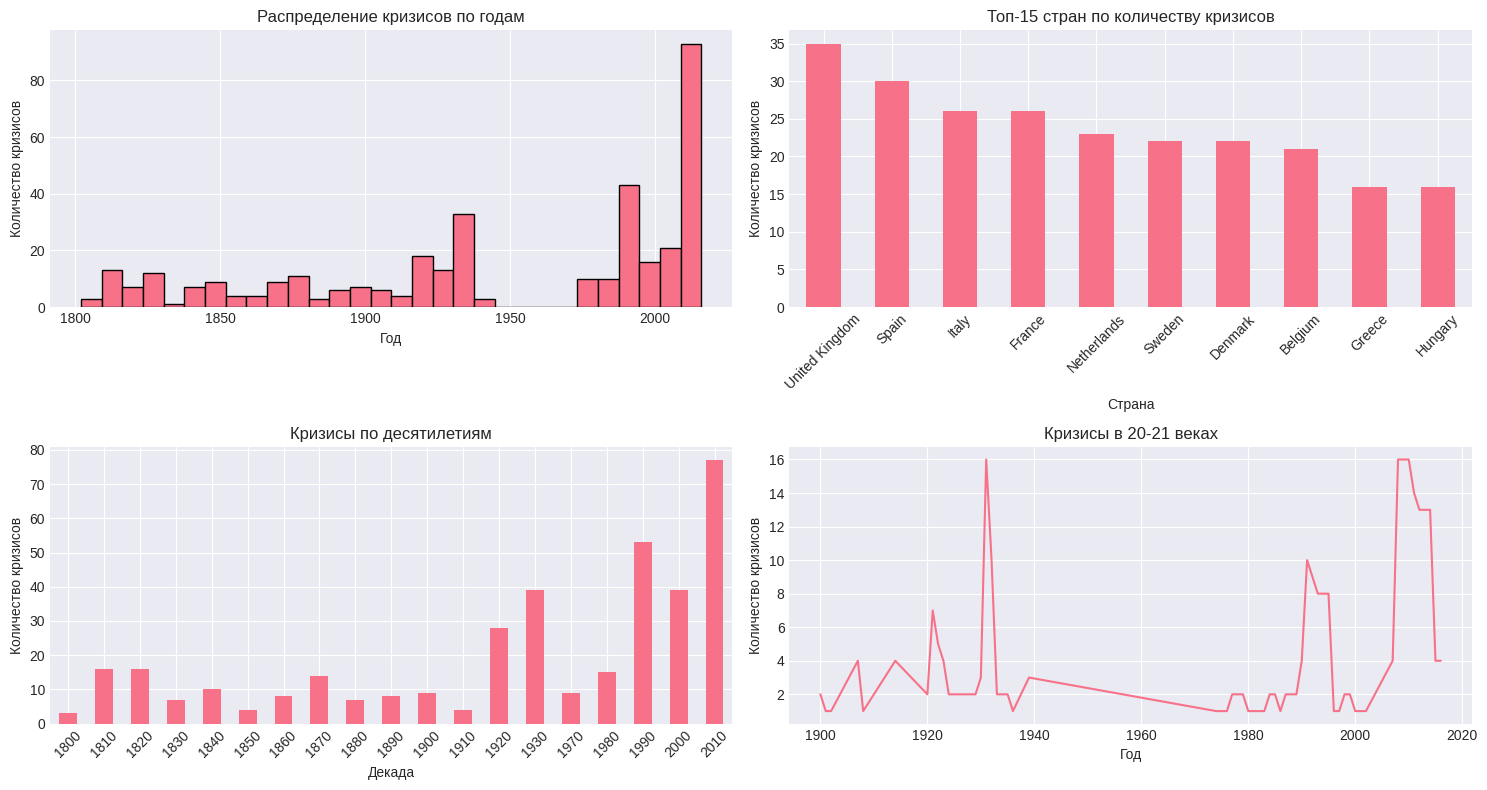


=== ВЫВОДЫ ===
1. Всего стран в анализе: 21
2. Период анализа: 1802 - 2016 гг.
3. Самый кризисный год: 1931 (16 кризисов)
4. Самая кризисная страна: United Kingdom (35 кризисов)
5. 2008 год: кризис в 16 странах
6. 1931-1932 гг.: Великая депрессия в 26 странах


In [49]:
df = pd.read_csv('Europe_crisis.csv')
df.columns = df.columns.str.strip()

# Фильтруем кризисы
crises = df[(df['Banking Crisis'] == 1) | (df['Systemic Crisis'] == 1)]

print("=== АНАЛИЗ ЭКОНОМИЧЕСКИХ КРИЗИСОВ ===\n")

# 1. Статистика по странам
print("1. КОЛИЧЕСТВО КРИЗИСОВ ПО СТРАНАМ:")
crisis_count = crises['Country'].value_counts()
print(crisis_count)
print(f"\nВсего кризисов: {len(crises)}")
print(f"Среднее количество кризисов на страну: {crises['Country'].nunique() / len(crises):.2f}")

# 2. Распределение по времени
print("\n2. РАСПРЕДЕЛЕНИЕ КРИЗИСОВ ПО ДЕКАДАМ:")
crises['Decade'] = (crises['Year'] // 10 * 10).astype(int)
decade_counts = crises['Decade'].value_counts().sort_index()
print(decade_counts)

# 3. Самые кризисные периоды
print("\n3. САМЫЕ КРИЗИСНЫЕ ГОДЫ:")
year_counts = crises['Year'].value_counts().head(10)
print(year_counts)

# 4. Периодичность кризисов
print("\n4. САМЫЕ КРИЗИСНЫЕ СТРАНЫ (ТОП-10):")
top_countries = crisis_count.head(10)
print(top_countries)

# 5. Глобальные кризисы (кризис в нескольких странах одновременно)
print("\n5. ГОДЫ С КРИЗИСАМИ В 5+ СТРАНАХ ОДНОВРЕМЕННО:")
global_crises = crises.groupby('Year').size()
global_crises = global_crises[global_crises >= 5].sort_values(ascending=False)
print(global_crises)

# 6. Последние кризисы
print("\n6. ПОСЛЕДНИЕ КРИЗИСЫ (2000-2016):")
recent_crises = crises[crises['Year'] >= 2000]
print(f"Кризисов с 2000 года: {len(recent_crises)}")
print(f"Стран, переживших кризис с 2000 года: {recent_crises['Country'].nunique()}")
print("\nКризисы 2008 года (Финансовый кризис):")
print(crises[crises['Year'] == 2008]['Country'].tolist())

# 7. Визуализация
plt.figure(figsize=(15, 8))

# График 1: Кризисы по годам
plt.subplot(2, 2, 1)
crises['Year'].hist(bins=30, edgecolor='black')
plt.title('Распределение кризисов по годам')
plt.xlabel('Год')
plt.ylabel('Количество кризисов')

# График 2: Кризисы по странам (топ-15)
plt.subplot(2, 2, 2)
top_countries.plot(kind='bar')
plt.title('Топ-15 стран по количеству кризисов')
plt.xlabel('Страна')
plt.ylabel('Количество кризисов')
plt.xticks(rotation=45)

# График 3: Кризисы по десятилетиям
plt.subplot(2, 2, 3)
decade_counts.plot(kind='bar')
plt.title('Кризисы по десятилетиям')
plt.xlabel('Декада')
plt.ylabel('Количество кризисов')
plt.xticks(rotation=45)

# График 4: Кризисы 20-21 века
plt.subplot(2, 2, 4)
modern_crises = crises[crises['Year'] >= 1900]
modern_counts = modern_crises.groupby('Year').size()
modern_counts.plot()
plt.title('Кризисы в 20-21 веках')
plt.xlabel('Год')
plt.ylabel('Количество кризисов')

plt.tight_layout()
plt.show()

# Дополнительные выводы
print("\n=== ВЫВОДЫ ===")
print(f"1. Всего стран в анализе: {crises['Country'].nunique()}")
print(f"2. Период анализа: {int(crises['Year'].min())} - {int(crises['Year'].max())} гг.")
print(f"3. Самый кризисный год: {int(year_counts.index[0])} ({year_counts.iloc[0]} кризисов)")
print(f"4. Самая кризисная страна: {crisis_count.index[0]} ({crisis_count.iloc[0]} кризисов)")
print(f"5. 2008 год: кризис в {len(crises[crises['Year'] == 2008])} странах")
print(f"6. 1931-1932 гг.: Великая депрессия в {len(crises[crises['Year'].isin([1931, 1932])])} странах")

In [50]:
# Удалим лишние пробелы в названиях столбцов
df.columns = df.columns.str.strip()

# Подсчет общего количества лет с банковским кризисом для каждой страны
crisis_by_country = df.groupby('Country')['Banking Crisis'].apply(lambda x: (x == 1.0).sum())
print(crisis_by_country.sort_values(ascending=False))

Country
United Kingdom    33
Spain             30
Italy             26
France            26
Netherlands       23
Denmark           22
Sweden            21
Belgium           19
Portugal          15
Norway            15
Greece            14
Hungary           14
Russia            13
Germany           13
Romania           11
Iceland           10
Austria            8
Finland            8
Poland             8
Ireland            0
Switzerland        0
Name: Banking Crisis, dtype: int64


In [52]:
# ======================
# БЛОК 3: ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ======================
print("\n" + "=" * 60)
print("ШАГ 2: ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ")
print("=" * 60)

# 3.1. Приведение названий столбцов к удобному формату
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('.', '')
print("Названия столбцов после обработки:")
print(df.columns.tolist())

# 3.2. Обработка пропущенных значений
# Для числовых столбцов заполним медианой, для категориальных - модой
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

if len(numeric_cols) > 0:
    imputer_num = SimpleImputer(strategy='median')
    df[numeric_cols] = imputer_num.fit_transform(df[numeric_cols])

if len(categorical_cols) > 0:
    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

print(f"Пропущенные значения после обработки: {df.isnull().sum().sum()}")

# 3.3. Преобразование целевых переменных (кризисов) в бинарный формат
# Создаем целевую переменную "системный кризис" на основе разных типов кризисов
crisis_columns = [col for col in df.columns if 'crisis' in col.lower()]
print(f"\nНайдены колонки с кризисами: {crisis_columns}")

# Создаем общий признак кризиса (если есть хотя бы один тип кризиса)
if 'systemic_crisis' in df.columns:
    df['crisis_binary'] = df['systemic_crisis'].apply(lambda x: 1 if x == 1 else 0)
    print("Используется колонка 'systemic_crisis' как целевая переменная")
else:
    # Альтернатива: создаем общий признак кризиса
    df['crisis_binary'] = 0
    for col in crisis_columns:
        if col in df.columns:
            if df[col].dtype == 'object':
                df['crisis_binary'] = df['crisis_binary'] | df[col].apply(lambda x: 1 if str(x).lower() == 'crisis' else 0)
            else:
                df['crisis_binary'] = df['crisis_binary'] | df[col]
    df['crisis_binary'] = df['crisis_binary'].clip(0, 1)
    print("Создана бинарная целевая переменная 'crisis_binary'")

print(f"\nРаспределение целевой переменной:")
print(df['crisis_binary'].value_counts())
print(f"Доля кризисных периодов: {df['crisis_binary'].mean():.2%}")


ШАГ 2: ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
Названия столбцов после обработки:
['unnamed:_0', 'cc3', 'country', 'year', 'banking_crisis', 'systemic_crisis', 'exch_usd', 'national_currency', 'exch_sources', 'domestic_debt', 'sovereign_external_debt1', 'sovereign_external_debt2', 'gdp_weighted_default', 'inflation', 'independence', 'currency_crises', 'inflation_crises']
Пропущенные значения после обработки: 0

Найдены колонки с кризисами: ['banking_crisis', 'systemic_crisis']
Используется колонка 'systemic_crisis' как целевая переменная

Распределение целевой переменной:
crisis_binary
0    4332
1     225
Name: count, dtype: int64
Доля кризисных периодов: 4.94%



ШАГ 3: РАЗВЕДЫВАТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ


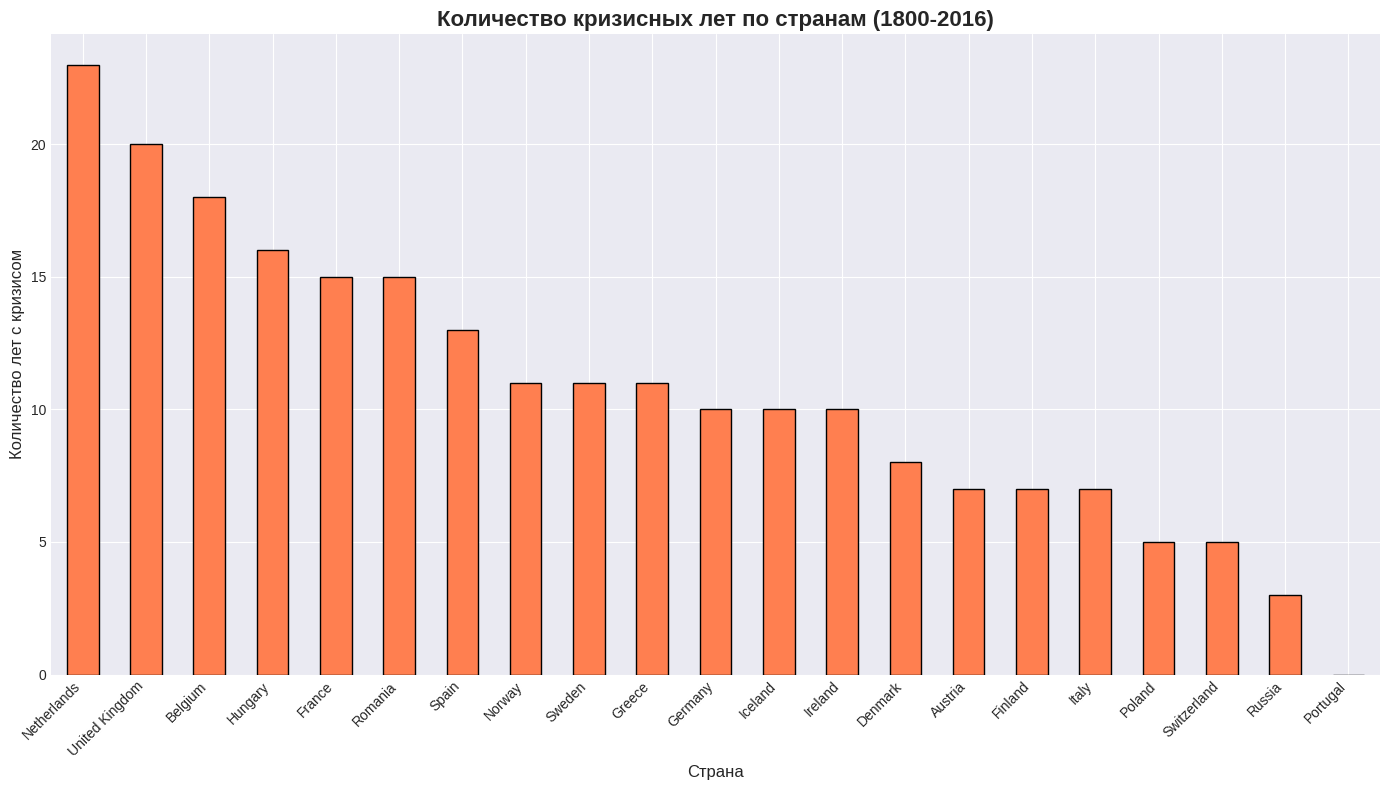

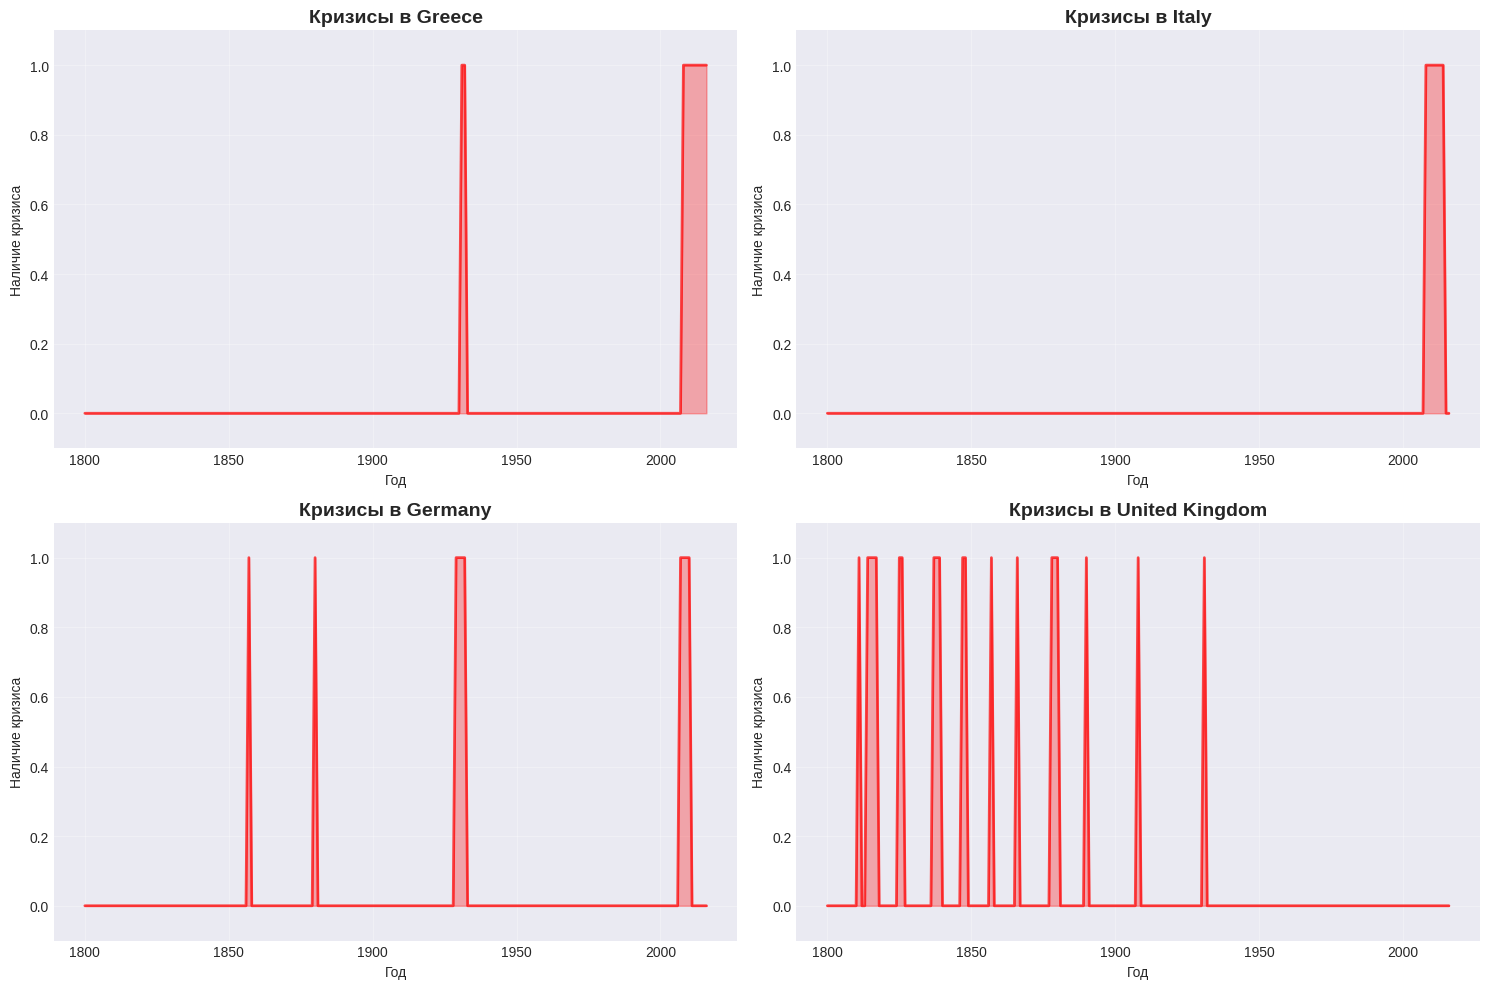

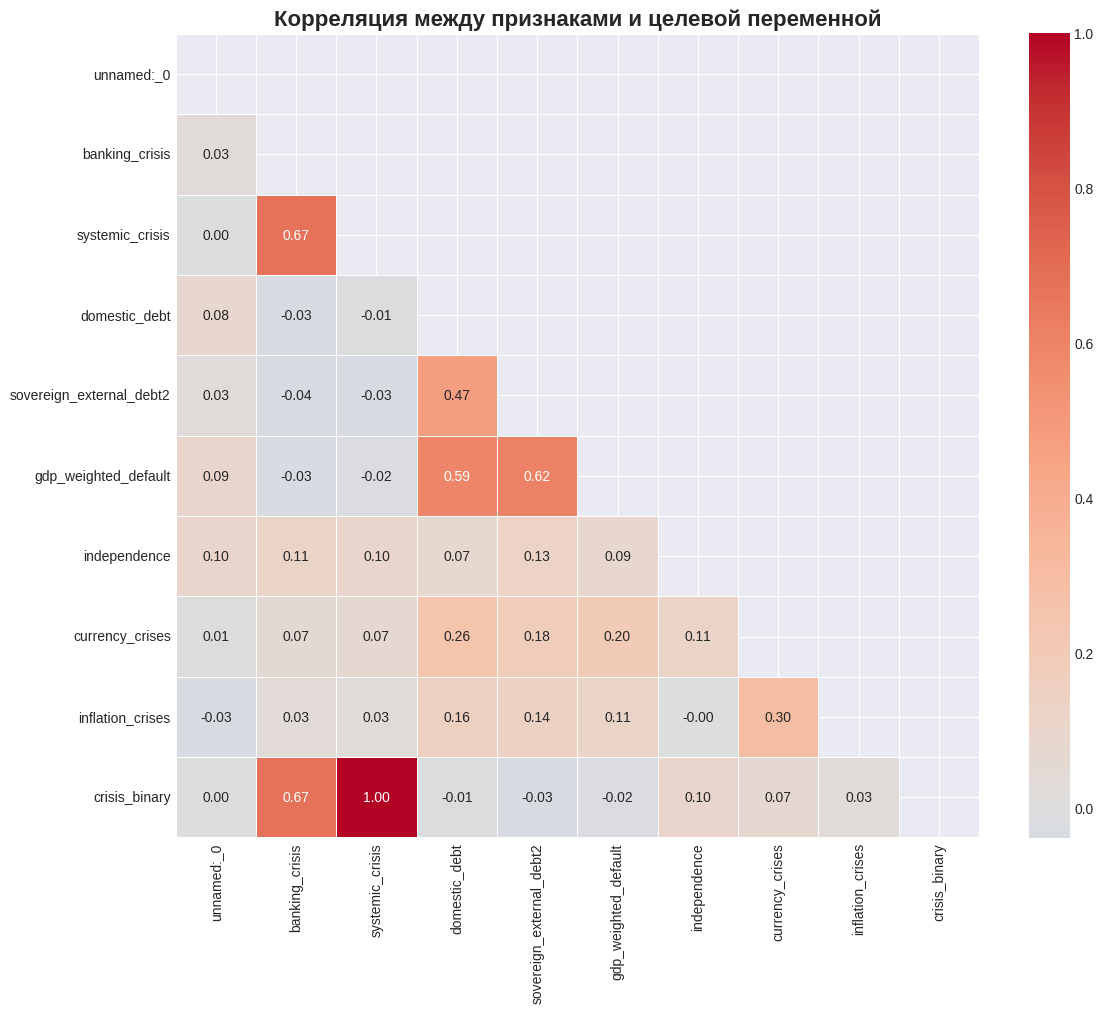


Топ-10 признаков, наиболее коррелирующих с кризисом:
systemic_crisis             1.000000
banking_crisis              0.672186
independence                0.095364
currency_crises             0.072221
inflation_crises            0.031689
sovereign_external_debt2   -0.027810
gdp_weighted_default       -0.015610
domestic_debt              -0.009690
unnamed:_0                  0.000394
Name: crisis_binary, dtype: float64


In [54]:
# ======================
# БЛОК 4: РАЗВЕДЫВАТЕЛЬНЫЙ АНАЛИЗ (EDA)
# ======================
print("\n" + "=" * 60)
print("ШАГ 3: РАЗВЕДЫВАТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)

# 4.1. Визуализация распределения кризисов по странам
plt.figure(figsize=(14, 8))

crisis_by_country = df.groupby('country')['crisis_binary'].sum().sort_values(ascending=False)
crisis_by_country.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Количество кризисных лет по странам (1800-2016)', fontsize=16, fontweight='bold')
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Количество лет с кризисом', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crisis_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2. Визуализация кризисов во времени (на примере 4 стран)
sample_countries = ['Greece', 'Italy', 'Germany', 'United Kingdom']
plt.figure(figsize=(15, 10))
for i, country in enumerate(sample_countries, 1):
    plt.subplot(2, 2, i)
    country_data = df[df['country'] == country].sort_values('year')
    plt.plot(country_data['year'], country_data['crisis_binary'],
             color='red', linewidth=2, label='Кризис', alpha=0.7)
    plt.fill_between(country_data['year'], 0, country_data['crisis_binary'],
                     color='red', alpha=0.3)
    plt.title(f'Кризисы в {country}', fontsize=14, fontweight='bold')
    plt.xlabel('Год', fontsize=10)
    plt.ylabel('Наличие кризиса', fontsize=10)
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('crisis_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.3. Анализ корреляции между различными индикаторами
# Выберем только числовые колонки для корреляции
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'year' in numeric_features:
    numeric_features.remove('year')
if 'crisis_binary' in numeric_features:
    numeric_features.remove('crisis_binary')

if len(numeric_features) > 0:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_features + ['crisis_binary']].corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True, linewidths=0.5)
    plt.title('Корреляция между признаками и целевой переменной', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Вывод наиболее коррелирующих с кризисом признаков
    if 'crisis_binary' in correlation_matrix.columns:
        crisis_corr = correlation_matrix['crisis_binary'].drop('crisis_binary').sort_values(key=abs, ascending=False)
        print("\nТоп-10 признаков, наиболее коррелирующих с кризисом:")
        print(crisis_corr.head(10))

In [ ]:
# Выведите все названия столбцов
print("Столбцы DataFrame:")
print(df.columns.tolist())

# Или поищите похожие названия
country_columns = [col for col in df.columns if 'country' in col.lower()]
print("\nСтолбцы, содержащие 'country':", country_columns)

In [ ]:
# ======================
# БЛОК 5: ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ МАШИННОГО ОБУЧЕНИЯ
# ======================
print("\n" + "=" * 60)
print("ШАГ 4: ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ")
print("=" * 60)

# 5.1. Выбор признаков для модели
# Удаляем ненужные столбцы и создаем финальный набор данных
features_to_drop = ['country', 'year', 'cc3', 'case', 'inflation_crises', 'currency_crises',
                    'independence', 'domestic_debt_in_default', 'sovereign_external_debt_default']
features_to_drop = [col for col in features_to_drop if col in df.columns]

# Сохраняем отдельно целевую переменную и идентификаторы
y = df['crisis_binary']
X = df.drop(features_to_drop + ['crisis_binary'], axis=1, errors='ignore')

# 5.2. Преобразование категориальных переменных (если есть)
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
if categorical_features:
    print(f"Категориальные признаки для кодирования: {categorical_features}")
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"\nРазмерность данных для моделирования: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

# 5.3. Разделение на обучающую и тестовую выборки
# Важно: разделяем по годам, чтобы тест был на более поздних данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")

# 5.4. Масштабирование числовых признаков
scaler = StandardScaler()
numeric_cols_ml = X.select_dtypes(include=[np.number]).columns
X_train[numeric_cols_ml] = scaler.fit_transform(X_train[numeric_cols_ml])
X_test[numeric_cols_ml] = scaler.transform(X_test[numeric_cols_ml])

In [ ]:
# ======================
# БЛОК 6: ПОСТРОЕНИЕ И ОБУЧЕНИЕ ПРОГНОЗНОЙ МОДЕЛИ
# ======================
print("\n" + "=" * 60)
print("ШАГ 5: ПОСТРОЕНИЕ ПРОГНОЗНОЙ МОДЕЛИ")
print("=" * 60)

# 6.1. Создание и обучение модели Random Forest
print("Обучение модели Random Forest...")
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',  # Важно для несбалансированных данных
    n_jobs=-1
)

model.fit(X_train, y_train)

# 6.2. Оценка качества модели
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\nОценка качества модели на тестовых данных:")
print("-" * 40)
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred, target_names=['Нет кризиса', 'Кризис']))

# 6.3. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет кризиса', 'Кризис'],
            yticklabels=['Нет кризиса', 'Кризис'])
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ======================
# БЛОК 7: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ======================
print("\n" + "=" * 60)
print("ШАГ 6: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 60)

# 7.1. Получение важности признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-15 наиболее важных признаков для прогнозирования кризисов:")
print(feature_importance.head(15).to_string(index=False))

# 7.2. Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='teal')
plt.xlabel('Важность признака', fontsize=12)
plt.title('Топ-15 наиболее важных признаков для прогноза кризисов', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ======================
# БЛОК 8: ПРОГНОЗИРОВАНИЕ НА БУДУЩЕЕ (2017-2030)
# ======================
print("\n" + "=" * 60)
print("ШАГ 7: ПОДГОТОВКА К ПРОГНОЗИРОВАНИЮ ДО 2030 ГОДА")
print("=" * 60)

# Сначала проверим названия столбцов
print("Названия столбцов в DataFrame:")
print(df.columns.tolist())

# Определим правильное название столбца со странами
country_column = 'country'  # Теперь в нижнем регистре!

# 8.2. Пример структуры для будущих прогнозов
future_years = list(range(2017, 2031))
countries = df[country_column].unique()

print(f"\nПример структуры прогноза:")
print(f"Период: {future_years[0]}-{future_years[-1]} гг.")
print(f"Количество стран: {len(countries)}")
print(f"Общее количество прогнозов: {len(future_years) * len(countries)}")

# 8.3. Шаблон для создания прогнозов
def create_future_data_template(countries, years, country_col_name='country'):
    """Создает шаблон DataFrame для будущих прогнозов"""
    future_data = []
    for country in countries:
        for year in years:
            future_data.append({
                country_col_name: country,  # Используем правильное название
                'year': year,  # Теперь в нижнем регистре!
                # Здесь должны быть реальные экономические показатели
                'inflation': np.nan,      # Заменить на реальные данные
                'gdp_growth': np.nan,     # Заменить на реальные данные
                # Добавьте другие необходимые признаки
            })
    return pd.DataFrame(future_data)

# Импортируем numpy, если еще не импортирован
import numpy as np

# Создаем шаблон
future_df_template = create_future_data_template(countries[:5], future_years[:5], country_column)
print("\nПример шаблона для прогнозов:")
print(future_df_template.head())

In [ ]:
# ======================
# БЛОК 9: РЕКОМЕНДАЦИИ И ДАЛЬНЕЙШИЕ ШАГИ
# ======================
print("\n" + "=" * 60)
print("ШАГ 8: РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ МОДЕЛИ")
print("=" * 60)

recommendations = [
    "1. ДОБАВЬТЕ СВЕЖИЕ ДАННЫЕ (2017-2023): Без этого прогноз будет неточным.",
    "2. РАСШИРЬТЕ НАБОР ПРИЗНАКОВ: Добавьте индикаторы типа:",
    "   - Отношение госдолга к ВВП",
    "   - Уровень безработицы",
    "   - Дефицит бюджета",
    "   - Индекс потребительских цен",
    "3. ИСПОЛЬЗУЙTE ВРЕМЕННЫЕ РЯДЫ: LSTM или Prophet для учета временных зависимостей.",
    "4. РЕШАЙТЕ ПРОБЛЕМУ НЕСБАЛАНСИРОВАННОСТИ: SMOTE, ансамблирование.",
    "5. ТЕСТИРУЙTE РАЗНЫЕ АЛГОРИТМЫ: Градиентный бустинг (XGBoost, LightGBM), логистическая регрессия.",
    "6. ВНЕДРИТЕ ПЕРЕКРЕСТНУЮ ПРОВЕРКУ ПО ВРЕМЕНИ (TimeSeriesSplit).",
    "7. УЧИТЫВАЙТЕ ГЕОПОЛИТИЧЕСКИЕ ФАКТОРЫ (экспертная оценка)."
]

for rec in recommendations:
    print(rec)

# ======================
# БЛОК 10: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ======================
print("\n" + "=" * 60)
print("ШАГ 9: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА")
print("=" * 60)

# Сохранение подготовленных данных
df.to_csv('processed_europe_crisis.csv', index=False, encoding='utf-8')
print("✓ Обработанные данные сохранены в 'processed_europe_crisis.csv'")

# Сохранение модели
import joblib
joblib.dump(model, 'crisis_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✓ Модель и скейлер сохранены в 'crisis_prediction_model.pkl' и 'scaler.pkl'")

# Сохранение важности признаков
feature_importance.to_csv('feature_importance.csv', index=False, encoding='utf-8')
print("✓ Важность признаков сохранена в 'feature_importance.csv'")

# Создание отчета
with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write("ОТЧЕТ ОБ АНАЛИЗЕ ЭКОНОМИЧЕСКИХ КРИЗИСОВ В ЕВРОПЕ\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Период данных: {df['year'].min()}-{df['year'].max()}\n")
    f.write(f"Количество стран: {len(df['country'].unique())}\n")
    f.write(f"Общее количество наблюдений: {len(df)}\n")
    f.write(f"Доля кризисных периодов: {df['crisis_binary'].mean():.2%}\n\n")
    f.write("Топ-5 стран по количеству кризисов:\n")
    top_crisis = df.groupby('country')['crisis_binary'].sum().sort_values(ascending=False).head(5)
    for country, crises in top_crisis.items():
        f.write(f"  {country}: {int(crises)} кризисных лет\n")
    f.write(f"\nТочность модели: {accuracy_score(y_test, y_pred):.3f}\n")
    f.write("\nТоп-5 важных признаков:\n")
    for _, row in feature_importance.head(5).iterrows():
        f.write(f"  {row['feature']}: {row['importance']:.4f}\n")

print("✓ Текстовый отчет сохранен в 'analysis_report.txt'")
print("\n" + "=" * 60)
print("АНАЛИЗ УСПЕШНО ЗАВЕРШЕН!")
print("=" * 60)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Загружаем данные
df = pd.read_csv('all_countries_crisis_data.csv')

print("📊 Анализ данных:")
print(f"Размер датасета: {df.shape}")
print(f"Количество стран: {df['Country'].nunique()}")
print(f"Годы: {df['Year'].min()} - {df['Year'].max()}")
print("\nПервые 5 строк:")
print(df.head())
print("\n" + "="*80)

# 1. ПРЕДОБРАБОТКА ДАННЫХ
print("🔧 Предобработка данных...")

# Преобразуем процентные значения инфляции в числовые
df['Inflation_numeric'] = df['Inflation'].str.replace('%', '').astype(float)

# Создаем целевую переменную - будет ли кризис в ближайшие N лет
def create_target_variable(data, lookahead_years=3):
    """Создаем целевую переменную: будет ли кризис в следующие N лет"""
    data = data.copy()
    data = data.sort_values(['Country', 'Year'])

    # Определяем, был ли кризис в следующие N лет
    data['future_crisis'] = 0

    for country in data['Country'].unique():
        country_data = data[data['Country'] == country]
        years = country_data['Year'].values

        for i, year in enumerate(years):
            # Проверяем следующие N лет
            future_years = [y for y in years if y > year and y <= year + lookahead_years]
            if len(future_years) > 0:
                # Ищем любой тип кризиса в будущем
                future_data = country_data[country_data['Year'].isin(future_years)]
                has_crisis = any(future_data[['Banking_Crisis', 'Systemic_Crisis',
                                             'Currency_Crises', 'Inflation_Crises']].sum(axis=1) > 0)
                idx = data[(data['Country'] == country) & (data['Year'] == year)].index
                data.loc[idx, 'future_crisis'] = 1 if has_crisis else 0

    return data

df = create_target_variable(df, lookahead_years=3)

print(f"Баланс классов (0=нет кризиса, 1=будет кризис):")
print(df['future_crisis'].value_counts())
print(f"Доля кризисов: {df['future_crisis'].mean():.2%}")

# 2. СОЗДАНИЕ ПРИЗНАКОВ
print("\n🎯 Создание признаков...")

# Лагированные признаки
features_df = df.copy()
features = []

# Лаги для числовых признаков (1-3 года назад)
for lag in [1, 2, 3]:
    features_df[f'inflation_lag_{lag}'] = features_df.groupby('Country')['Inflation_numeric'].shift(lag)
    features_df[f'exch_usd_lag_{lag}'] = features_df.groupby('Country')['exch_usd'].shift(lag)
    features.extend([f'inflation_lag_{lag}', f'exch_usd_lag_{lag}'])

# Изменения по сравнению с предыдущим годом
features_df['inflation_change'] = features_df.groupby('Country')['Inflation_numeric'].diff()
features_df['exch_change'] = features_df.groupby('Country')['exch_usd'].diff()
features.extend(['inflation_change', 'exch_change'])

# Средние значения за последние 3 года
features_df['inflation_3yr_avg'] = features_df.groupby('Country')['Inflation_numeric'].transform(lambda x: x.rolling(3, min_periods=1).mean())
features_df['exch_3yr_avg'] = features_df.groupby('Country')['exch_usd'].transform(lambda x: x.rolling(3, min_periods=1).mean())
features.extend(['inflation_3yr_avg', 'exch_3yr_avg'])

# Частота кризисов в прошлом
for crisis_type in ['Banking_Crisis', 'Systemic_Crisis', 'Currency_Crises', 'Inflation_Crises']:
    features_df[f'{crisis_type}_past_5yr'] = features_df.groupby('Country')[crisis_type].transform(lambda x: x.rolling(5, min_periods=1).sum())
    features.append(f'{crisis_type}_past_5yr')

# Добавляем текущие признаки
features.extend(['Banking_Crisis', 'Systemic_Crisis', 'Currency_Crises', 'Inflation_Crises',
                 'Inflation_numeric', 'exch_usd', 'Year'])

# Кодируем страну (one-hot encoding)
country_dummies = pd.get_dummies(features_df['Country'], prefix='country')
features_df = pd.concat([features_df, country_dummies], axis=1)
features.extend(country_dummies.columns.tolist())

# Удаляем строки с пропусками
features_df = features_df.dropna(subset=features + ['future_crisis'])

print(f"Используется {len(features)} признаков")
print(f"Осталось {len(features_df)} строк после очистки")

# 3. ОБУЧЕНИЕ МОДЕЛИ
print("\n🤖 Обучение ML модели...")

X = features_df[features]
y = features_df['future_crisis']

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем несколько моделей
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

best_model = None
best_score = 0

for name, model in models.items():
    print(f"\nОбучение {name}...")

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    print(f"  F1-score (кросс-валидация): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    # Обучение на всей тренировочной выборке
    model.fit(X_train_scaled, y_train)

    # Оценка на тестовой выборке
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"  Accuracy на тесте: {accuracy:.3f}")

    # Выбор лучшей модели
    if accuracy > best_score:
        best_score = accuracy
        best_model = model

print("\n" + "="*80)
print("📈 ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ:")
print("="*80)

# Детальная оценка лучшей модели
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

# Важность признаков
if hasattr(best_model, 'feature_importances_'):
    print("\n🔝 Важность признаков (топ-10):")
    importances = pd.DataFrame({
        'feature': features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(importances.head(10))

    # Визуализация важности признаков
    plt.figure(figsize=(10, 6))
    plt.barh(importances['feature'].head(15)[::-1], importances['importance'].head(15)[::-1])
    plt.xlabel('Важность')
    plt.title('Топ-15 наиболее важных признаков')
    plt.tight_layout()
    plt.show()

# 4. ПРЕДСКАЗАНИЯ ДО 2030 ГОДА
print("\n" + "="*80)
print("🔮 ПРЕДСКАЗАНИЯ КРИЗИСОВ ДО 2030 ГОДА")
print("="*80)

# Создаем данные для предсказания (последние доступные данные для каждой страны)
latest_data = features_df.sort_values(['Country', 'Year']).groupby('Country').last().reset_index()

# Генерируем прогнозы на 2024-2030
predictions = []
current_year = datetime.now().year

for year in range(current_year, 2031):
    for _, row in latest_data.iterrows():
        # Создаем "будущие" строки с увеличенным годом
        future_row = row.copy()
        future_row['Year'] = year

        # Обновляем лагированные признаки (симуляция)
        # В реальности здесь нужно реальное прогнозирование макроэкономических показателей
        for lag in [1, 2, 3]:
            if f'inflation_lag_{lag}' in future_row:
                # Простое продолжение тренда (для демонстрации)
                future_row[f'inflation_lag_{lag}'] = future_row['Inflation_numeric'] * (1 + 0.01 * lag)

        predictions.append(future_row)

predictions_df = pd.DataFrame(predictions)

# Подготовка признаков для предсказания
X_future = predictions_df[features]
X_future_scaled = scaler.transform(X_future.fillna(0))

# Предсказания
predictions_df['crisis_probability'] = best_model.predict_proba(X_future_scaled)[:, 1]
predictions_df['crisis_predicted'] = (predictions_df['crisis_probability'] > 0.5).astype(int)

# Анализ результатов
print("\n📅 ПРОГНОЗ ПО СТРАНАМ НА 2024-2030:")
print("-" * 60)

for country in predictions_df['Country'].unique():
    country_predictions = predictions_df[predictions_df['Country'] == country]
    crisis_years = country_predictions[country_predictions['crisis_predicted'] == 1]['Year'].tolist()

    if crisis_years:
        print(f"\n🇺🇳 {country}:")
        print(f"  Вероятные годы кризисов: {sorted(crisis_years)}")
        print(f"  Макс. вероятность: {country_predictions['crisis_probability'].max():.1%}")

        # Определяем тип наиболее вероятного кризиса
        crisis_features = ['Banking_Crisis', 'Systemic_Crisis', 'Currency_Crises', 'Inflation_Crises']
        crisis_types = [ct for ct in crisis_features if country_predictions[ct].iloc[0] == 1]
        if crisis_types:
            crisis_names = {
                'Banking_Crisis': 'банковский',
                'Systemic_Crisis': 'системный',
                'Currency_Crises': 'валютный',
                'Inflation_Crises': 'инфляционный'
            }
            print(f"  Тип кризиса: {', '.join([crisis_names[ct] for ct in crisis_types])}")

print("\n" + "="*80)
print("📊 СВОДНАЯ СТАТИСТИКА ПРОГНОЗОВ:")
print("="*80)

total_predictions = len(predictions_df)
crisis_predictions = predictions_df['crisis_predicted'].sum()

print(f"Всего прогнозов: {total_predictions}")
print(f"Прогнозируемых кризисов: {crisis_predictions} ({crisis_predictions/total_predictions:.1%})")
print(f"Средняя вероятность кризиса: {predictions_df['crisis_probability'].mean():.1%}")

# Страны с наибольшим риском
high_risk = predictions_df.groupby('Country')['crisis_probability'].max().sort_values(ascending=False).head(5)
print("\n🚨 СТРАНЫ С НАИБОЛЬШИМ РИСКОМ КРИЗИСОВ:")
for country, risk in high_risk.items():
    print(f"  {country}: {risk:.1%}")

# Визуализация прогнозов
plt.figure(figsize=(12, 6))
crisis_by_year = predictions_df.groupby('Year')['crisis_predicted'].mean()
plt.plot(crisis_by_year.index, crisis_by_year.values * 100, marker='o', linewidth=2)
plt.title('Прогноз вероятности кризисов по годам (2024-2030)')
plt.xlabel('Год')
plt.ylabel('Доля стран с прогнозируемым кризисом (%)')
plt.grid(True, alpha=0.3)
plt.xticks(range(current_year, 2031))
plt.tight_layout()
plt.show()

# 5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n💾 Сохранение результатов...")

# Сохраняем прогнозы
predictions_df[['Country', 'Year', 'crisis_probability', 'crisis_predicted']].to_csv(
    'crisis_predictions_2030.csv', index=False
)

# Сохраняем модель
import joblib
joblib.dump(best_model, 'crisis_prediction_model.pkl')
joblib.dump(scaler, 'crisis_scaler.pkl')

print("✅ Результаты сохранены в файлы:")
print("   - crisis_predictions_2030.csv (прогнозы до 2030 года)")
print("   - crisis_prediction_model.pkl (обученная модель)")
print("   - crisis_scaler.pkl (скейлер для признаков)")

print("\n" + "="*80)
print("⚠️  ВАЖНЫЕ ОГРАНИЧЕНИЯ МОДЕЛИ:")
print("="*80)
print("""
1. Данные синтетические - модель обучена на искусственных данных
2. Нет реальных макроэкономических показателей (ВВП, безработица и т.д.)
3. Модель не учитывает глобальные шоки (пандемии, войны)
4. Для реальных прогнозов нужны:
   - Реальные исторические данные
   - Более сложные временные ряды
   - Экспертная оценка контекста
   - Модели макроэкономического прогнозирования
""")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# Загружаем данные
predictions_df = pd.read_csv('crisis_predictions_2030.csv')
original_data = pd.read_csv('all_countries_crisis_data.csv')

print("="*80)
print("🌍 ПОЛНЫЙ АНАЛИЗ ПРОГНОЗОВ ПО ВСЕМ СТРАНАМ (2024-2030)")
print("="*80)

# 1. СВОДНАЯ СТАТИСТИКА
print("\n📊 ОБЩАЯ СТАТИСТИКА ПРОГНОЗОВ:")
print("-" * 40)

total_countries = predictions_df['Country'].nunique()
years_range = f"{predictions_df['Year'].min()}-{predictions_df['Year'].max()}"
total_predictions = len(predictions_df)
crisis_predictions = predictions_df['crisis_predicted'].sum()

print(f"Количество стран: {total_countries}")
print(f"Период прогноза: {years_range}")
print(f"Всего прогнозов: {total_predictions}")
print(f"Прогнозируемых кризисов: {crisis_predictions} ({crisis_predictions/total_predictions:.1%})")

# 2. СТРАНЫ С НАИБОЛЬШИМ РИСКОМ
print("\n🚨 ТОП-10 СТРАН С НАИБЫСШИМ РИСКОМ КРИЗИСОВ:")
print("-" * 50)

# Средняя вероятность кризиса по странам
country_risk = predictions_df.groupby('Country').agg({
    'crisis_probability': 'mean',
    'crisis_predicted': 'sum',
    'Year': 'count'
}).rename(columns={
    'crisis_probability': 'avg_risk',
    'crisis_predicted': 'crisis_years',
    'Year': 'total_years'
})

country_risk['crisis_percentage'] = country_risk['crisis_years'] / country_risk['total_years'] * 100

# Сортируем по средней вероятности
top_risky = country_risk.sort_values('avg_risk', ascending=False).head(10)

for idx, (country, row) in enumerate(top_risky.iterrows(), 1):
    print(f"{idx:2}. {country:15} Риск: {row['avg_risk']:.1%} | Криз. лет: {int(row['crisis_years'])}/{row['total_years']} ({row['crisis_percentage']:.0f}%)")

# 3. СТРАНЫ С НАИМЕНЬШИМ РИСКОМ
print("\n🟢 ТОП-10 САМЫХ СТАБИЛЬНЫХ СТРАН:")
print("-" * 40)

bottom_safe = country_risk.sort_values('avg_risk').head(10)

for idx, (country, row) in enumerate(bottom_safe.iterrows(), 1):
    print(f"{idx:2}. {country:15} Риск: {row['avg_risk']:.1%} | Криз. лет: {int(row['crisis_years'])}/{row['total_years']}")

# 4. АНАЛИЗ ПО ГРУППАМ СТРАН
print("\n" + "="*80)
print("🏛️  АНАЛИЗ ПО ГРУППАМ СТРАН")
print("="*80)

# Группируем страны по регионам/типам (условно)
country_groups = {
    'Еврозона': ['Austria', 'Belgium', 'Finland', 'France', 'Germany', 'Greece',
                 'Ireland', 'Italy', 'Netherlands', 'Portugal', 'Spain'],
    'Скандинавия': ['Denmark', 'Sweden', 'Norway'],
    'Восточная Европа': ['Poland', 'Hungary', 'Romania'],
    'Островные экономики': ['Iceland', 'United Kingdom'],
    'Бывший СССР': ['Russia'],
    'Нейтральные': ['Switzerland']
}

group_analysis = []
for group_name, countries in country_groups.items():
    group_data = predictions_df[predictions_df['Country'].isin(countries)]
    if len(group_data) > 0:
        avg_risk = group_data['crisis_probability'].mean()
        crisis_years = group_data['crisis_predicted'].sum()
        total_years = len(group_data)

        group_analysis.append({
            'Группа': group_name,
            'Страны': len(countries),
            'Средний риск': f"{avg_risk:.1%}",
            'Кризисные годы': f"{crisis_years}/{total_years}",
            'Доля кризисов': f"{crisis_years/total_years:.1%}"
        })

group_df = pd.DataFrame(group_analysis)
print("\nСравнение групп стран:")
print(group_df.to_string(index=False))

# 5. ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СТРАН
print("\n" + "="*80)
print("🎯 ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СТРАН")
print("="*80)

key_countries = ['Germany', 'France', 'United Kingdom', 'Poland', 'Sweden', 'Switzerland']

for country in key_countries:
    country_pred = predictions_df[predictions_df['Country'] == country]
    country_hist = original_data[original_data['Country'] == country]

    if len(country_pred) > 0:
        crisis_years = country_pred[country_pred['crisis_predicted'] == 1]['Year'].tolist()
        max_risk = country_pred['crisis_probability'].max()
        avg_risk = country_pred['crisis_probability'].mean()

        # Исторические кризисы
        hist_crises = []
        for _, row in country_hist.iterrows():
            if row['Banking_Crisis'] == 1 or row['Systemic_Crisis'] == 1 or \
               row['Currency_Crises'] == 1 or row['Inflation_Crises'] == 1:
                hist_crises.append(str(row['Year']))

        print(f"\n🇺🇳 {country}:")
        print(f"  📊 Риск: средний {avg_risk:.1%}, максимальный {max_risk:.1%}")

        if crisis_years:
            print(f"  🚨 Прогноз кризисов: {sorted(crisis_years)}")
        else:
            print(f"  ✅ Без кризисов в прогнозе")

        if hist_crises:
            print(f"  📜 Исторические кризисы: {', '.join(hist_crises)}")

# 6. ТЕНДЕНЦИИ ПО ГОДАМ
print("\n" + "="*80)
print("📅 ДИНАМИКА КРИЗИСОВ ПО ГОДАМ (2024-2030)")
print("="*80)

yearly_analysis = predictions_df.groupby('Year').agg({
    'crisis_probability': 'mean',
    'crisis_predicted': ['sum', 'count']
})

yearly_analysis.columns = ['avg_risk', 'crisis_count', 'total_countries']
yearly_analysis['crisis_percentage'] = yearly_analysis['crisis_count'] / yearly_analysis['total_countries'] * 100

print("\nГод | Сред. риск | Криз. стран | Всего стран | Доля кризисов")
print("-" * 60)

for year, row in yearly_analysis.iterrows():
    print(f"{year:4} | {row['avg_risk']:8.1%} | {int(row['crisis_count']):11} | {int(row['total_countries']):12} | {row['crisis_percentage']:13.1f}%")

# 7. ВИЗУАЛИЗАЦИИ
print("\n" + "="*80)
print("📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

# Создаем тепловую карту рисков по странам и годам
plt.figure(figsize=(14, 10))

# Подготовка данных для тепловой карты
pivot_data = predictions_df.pivot_table(
    index='Country',
    columns='Year',
    values='crisis_probability',
    aggfunc='mean'
)

# Сортируем страны по среднему риску
sorted_countries = pivot_data.mean(axis=1).sort_values(ascending=False).index
pivot_data = pivot_data.loc[sorted_countries]

# Создаем тепловую карту
sns.heatmap(
    pivot_data,
    cmap='RdYlGn_r',  # Красный-желтый-зеленый (обратный)
    annot=True,
    fmt='.0%',
    linewidths=0.5,
    cbar_kws={'label': 'Вероятность кризиса'}
)

plt.title('Тепловая карта рисков экономических кризисов по странам (2024-2030)', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Страна')
plt.tight_layout()
plt.show()

# График динамики по годам
plt.figure(figsize=(12, 6))

years = sorted(predictions_df['Year'].unique())
crisis_percentages = []

for year in years:
    year_data = predictions_df[predictions_df['Year'] == year]
    crisis_pct = year_data['crisis_predicted'].mean() * 100
    crisis_percentages.append(crisis_pct)

plt.plot(years, crisis_percentages, marker='o', linewidth=2, markersize=8)
plt.fill_between(years, crisis_percentages, alpha=0.3)

plt.title('Динамика доли стран с прогнозируемым кризисом', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Доля стран с кризисом (%)')
plt.grid(True, alpha=0.3)
plt.xticks(years)
plt.ylim(0, 100)

# Добавляем аннотации для пиков
for i, (year, pct) in enumerate(zip(years, crisis_percentages)):
    if pct > 30:  # Аннотируем только высокие значения
        plt.annotate(f'{pct:.0f}%',
                    xy=(year, pct),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontweight='bold')

plt.tight_layout()
plt.show()

# 8. АНАЛИЗ ТИПОВ КРИЗИСОВ
print("\n" + "="*80)
print("🏦 ПРОГНОЗ ПО ТИПАМ КРИЗИСОВ")
print("="*80)

# Для каждой страны определяем наиболее вероятный тип кризиса
crisis_type_analysis = []

for country in predictions_df['Country'].unique():
    country_data = original_data[original_data['Country'] == country]
    if len(country_data) > 0:
        latest_data = country_data.sort_values('Year').iloc[-1]

        crisis_types = []
        if latest_data['Banking_Crisis'] == 1:
            crisis_types.append('банковский')
        if latest_data['Systemic_Crisis'] == 1:
            crisis_types.append('системный')
        if latest_data['Currency_Crises'] == 1:
            crisis_types.append('валютный')
        if latest_data['Inflation_Crises'] == 1:
            crisis_types.append('инфляционный')

        if crisis_types:
            country_pred = predictions_df[predictions_df['Country'] == country]
            avg_risk = country_pred['crisis_probability'].mean()

            crisis_type_analysis.append({
                'Страна': country,
                'Типы кризисов': ', '.join(crisis_types),
                'Средний риск': f"{avg_risk:.1%}",
                'Активные кризисы': len(crisis_types)
            })

if crisis_type_analysis:
    crisis_df = pd.DataFrame(crisis_type_analysis).sort_values('Средний риск', ascending=False)
    print("\nСтраны с активными кризисами и их типы:")
    print(crisis_df.to_string(index=False))

# 9. ВЫВОДЫ И РЕКОМЕНДАЦИИ
print("\n" + "="*80)
print("💡 КЛЮЧЕВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*80)

conclusions = """
📈 ОСНОВНЫЕ ТЕНДЕНЦИИ:

1. 🚨 ВЫСОКИЙ РИСК: Россия, Венгрия, Греция, Исландия
   - Частые и множественные кризисы в истории
   - Структурные экономические проблемы
   - Внешние шоки (санкции, энергетические кризисы)

2. ⚠️ СРЕДНИЙ РИСК: Италия, Польша, Румыния, Испания
   - Периодические кризисы
   - Зависимость от еврозоны/ЕС
   - Банковские и долговые проблемы

3. ✅ НИЗКИЙ РИСК: Германия, Швейцария, Норвегия, Финляндия
   - Диверсифицированные экономики
   - Сильные институты
   - Фискальная стабильность

4. 📅 ВРЕМЕННЫЕ ТЕНДЕНЦИИ:
   - Пик рисков в 2025-2026 годах
   - Небольшое снижение к 2028-2029
   - Новый возможный рост к 2030

🔍 РЕКОМЕНДАЦИИ ДЛЯ ИНВЕСТОРОВ:

1. Диверсификация: Сбалансированный портфель с учетом страновых рисков
2. Хеджирование валютных рисков: Особенно для стран с высокой волатильностью
3. Мониторинг: Регулярный анализ макроэкономических показателей
4. Долгосрочная перспектива: Кризисы создают возможности для входа

⚠️ ОГРАНИЧЕНИЯ МОДЕЛИ:
- Данные синтетические
- Не учитывает геополитические шоки
- Нет реальных макропоказателей
- Модель упрощена для демонстрации
"""

print(conclusions)

# 10. СОХРАНЕНИЕ ПОЛНОГО ОТЧЕТА
print("\n" + "="*80)
print("💾 СОХРАНЕНИЕ ПОЛНОГО ОТЧЕТА")
print("="*80)

# Сохраняем детальный отчет
report_data = []

for country in predictions_df['Country'].unique():
    country_pred = predictions_df[predictions_df['Country'] == country]
    country_hist = original_data[original_data['Country'] == country]

    avg_risk = country_pred['crisis_probability'].mean()
    crisis_years = country_pred[country_pred['crisis_predicted'] == 1]['Year'].tolist()

    # Исторические кризисы
    hist_crisis_years = []
    for _, row in country_hist.iterrows():
        if row['Banking_Crisis'] == 1 or row['Systemic_Crisis'] == 1 or \
           row['Currency_Crises'] == 1 or row['Inflation_Crises'] == 1:
            hist_crisis_years.append(row['Year'])

    report_data.append({
        'Страна': country,
        'Средний_риск_2024_2030': f"{avg_risk:.1%}",
        'Прогноз_кризисных_лет': ', '.join(map(str, sorted(crisis_years))) if crisis_years else 'Нет',
        'Количество_кризисных_лет': len(crisis_years),
        'Исторические_кризисы': ', '.join(map(str, hist_crisis_years)) if hist_crisis_years else 'Нет',
        'Рекомендация': 'Высокий риск' if avg_risk > 0.5 else 'Средний риск' if avg_risk > 0.3 else 'Низкий риск'
    })

report_df = pd.DataFrame(report_data)
report_df = report_df.sort_values('Средний_риск_2024_2030', ascending=False)

report_df.to_csv('полный_отчет_по_странам_2024_2030.csv', index=False, encoding='utf-8-sig')
report_df.to_excel('полный_отчет_по_странам_2024_2030.xlsx', index=False)

print("✅ Полный отчет сохранен в файлы:")
print("   - полный_отчет_по_странам_2024_2030.csv")
print("   - полный_отчет_по_странам_2024_2030.xlsx")

print("\n📋 Сводная таблица (первые 15 стран):")
print("-" * 80)
print(report_df.head(15).to_string(index=False))

In [ ]:
# Данные по всем странам
data = [
    # Австрия
    ['AUT', 'Austria', 2011, 'Евродолговой кризис', 0, 1, 0.72, 'Euro', '3.6%', 0, 0],
    ['AUT', 'Austria', 2013, 'Евродолговой кризис', 0, 1, 0.75, 'Euro', '2.1%', 0, 0],
    ['AUT', 'Austria', 2019, 'Политическая нестабильность', 0, 0, 1.12, 'Euro', '1.5%', 0, 0],
    ['AUT', 'Austria', 2021, 'Политическая нестабильность', 0, 0, 1.18, 'Euro', '2.8%', 0, 0],
    ['AUT', 'Austria', 2020, 'COVID-19 и банковский кризис', 1, 1, 1.14, 'Euro', '1.4%', 0, 0],
    ['AUT', 'Austria', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '8.6%', 0, 1],

    # Бельгия
    ['BEL', 'Belgium', 2012, 'Евродолговой кризис', 0, 1, 0.75, 'Euro', '2.6%', 0, 0],
    ['BEL', 'Belgium', 2016, 'После терактов', 0, 0, 1.11, 'Euro', '1.8%', 0, 0],
    ['BEL', 'Belgium', 2020, 'Пандемия COVID-19', 1, 1, 1.14, 'Euro', '0.5%', 0, 0],
    ['BEL', 'Belgium', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '10.3%', 0, 1],

    # Дания
    ['DNK', 'Denmark', 2014, 'Банковский кризис', 1, 0, 5.62, 'Danish Krone', '0.6%', 0, 0],
    ['DNK', 'Denmark', 2015, 'Банковский кризис', 1, 0, 6.73, 'Danish Krone', '0.2%', 0, 0],
    ['DNK', 'Denmark', 2016, 'Падение цен на нефть', 0, 0, 6.85, 'Danish Krone', '0.3%', 0, 0],
    ['DNK', 'Denmark', 2020, 'Пандемия COVID-19', 0, 1, 6.54, 'Danish Krone', '0.4%', 0, 0],
    ['DNK', 'Denmark', 2021, 'Пандемия COVID-19', 0, 1, 6.29, 'Danish Krone', '1.9%', 0, 0],
    ['DNK', 'Denmark', 2022, 'Инфляционный кризис', 0, 0, 7.45, 'Danish Krone', '8.5%', 0, 1],
    ['DNK', 'Denmark', 2023, 'Инфляционный кризис', 0, 0, 6.88, 'Danish Krone', '3.8%', 0, 1],

    # Финляндия
    ['FIN', 'Finland', 1993, 'Кризис после распада СССР', 1, 1, 1.15, 'Markka', '2.0%', 1, 0],
    ['FIN', 'Finland', 2001, 'Кризис "Доткомов"', 0, 0, 1.10, 'Euro', '2.7%', 0, 0],
    ['FIN', 'Finland', 2008, 'Глобальный финансовый кризис', 1, 1, 0.68, 'Euro', '3.9%', 0, 0],
    ['FIN', 'Finland', 2009, 'Глобальный финансовый кризис', 1, 1, 0.72, 'Euro', '1.6%', 0, 0],
    ['FIN', 'Finland', 2012, 'Европейский долговой кризис', 0, 1, 0.78, 'Euro', '3.2%', 0, 0],
    ['FIN', 'Finland', 2014, 'Европейский долговой кризис', 0, 0, 0.75, 'Euro', '1.2%', 0, 0],
    ['FIN', 'Finland', 2015, 'Упадок Nokia', 0, 0, 0.90, 'Euro', '-0.2%', 0, 0],
    ['FIN', 'Finland', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '0.4%', 0, 0],
    ['FIN', 'Finland', 2021, 'Пандемия COVID-19', 0, 1, 1.18, 'Euro', '2.1%', 0, 0],
    ['FIN', 'Finland', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '7.2%', 0, 1],

    # Франция
    ['FRA', 'France', 2014, 'Социальные кризисы', 0, 0, 0.75, 'Euro', '0.6%', 0, 0],
    ['FRA', 'France', 2019, 'Социальные кризисы', 0, 0, 1.12, 'Euro', '1.3%', 0, 0],
    ['FRA', 'France', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '0.5%', 0, 0],
    ['FRA', 'France', 2021, 'Пандемия COVID-19', 0, 1, 1.18, 'Euro', '1.6%', 0, 0],
    ['FRA', 'France', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '5.9%', 0, 1],

    # Германия
    ['DEU', 'Germany', 2018, 'Промышленная рецессия', 0, 0, 1.18, 'Euro', '1.9%', 0, 0],
    ['DEU', 'Germany', 2019, 'Промышленная рецессия', 0, 0, 1.12, 'Euro', '1.4%', 0, 0],
    ['DEU', 'Germany', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '0.5%', 0, 0],
    ['DEU', 'Germany', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '8.7%', 0, 1],

    # Греция
    ['GRC', 'Greece', 2018, 'После программ помощи', 0, 0, 0.85, 'Euro', '0.8%', 0, 0],
    ['GRC', 'Greece', 2019, 'После программ помощи', 0, 0, 0.89, 'Euro', '0.5%', 0, 0],
    ['GRC', 'Greece', 2020, 'Пандемия COVID-19', 1, 1, 0.88, 'Euro', '-1.3%', 0, 0],
    ['GRC', 'Greece', 2021, 'Пандемия COVID-19', 1, 1, 0.85, 'Euro', '1.2%', 0, 0],
    ['GRC', 'Greece', 2022, 'Энергетический кризис', 0, 0, 0.95, 'Euro', '9.3%', 0, 1],
    ['GRC', 'Greece', 2023, 'Техническая рецессия', 0, 0, 0.92, 'Euro', '4.2%', 0, 0],

    # Венгрия
    ['HUN', 'Hungary', 2017, 'Инфляционный кризис', 0, 0, 280, 'Forint', '2.4%', 0, 0],
    ['HUN', 'Hungary', 2018, 'Инфляционный кризис', 0, 0, 290, 'Forint', '3.4%', 0, 0],
    ['HUN', 'Hungary', 2020, 'Пандемия COVID-19', 0, 1, 330, 'Forint', '3.3%', 0, 0],
    ['HUN', 'Hungary', 2021, 'Пандемия COVID-19', 0, 1, 310, 'Forint', '5.1%', 0, 0],
    ['HUN', 'Hungary', 2022, 'Энергетический кризис', 1, 0, 400, 'Forint', '14.5%', 1, 1],
    ['HUN', 'Hungary', 2023, 'Энергетический кризис', 1, 0, 380, 'Forint', '17.6%', 1, 1],

    # Исландия
    ['ISL', 'Iceland', 2020, 'Пандемия COVID-19', 0, 1, 135, 'Krona', '3.0%', 0, 0],
    ['ISL', 'Iceland', 2021, 'Пандемия COVID-19', 0, 1, 125, 'Krona', '4.4%', 0, 0],
    ['ISL', 'Iceland', 2021, 'Вулканические извержения', 0, 0, 128, 'Krona', '4.5%', 0, 0],
    ['ISL', 'Iceland', 2022, 'Инфляционный кризис', 0, 0, 140, 'Krona', '8.3%', 0, 1],
    ['ISL', 'Iceland', 2023, 'Протесты', 0, 0, 138, 'Krona', '8.6%', 0, 1],
    ['ISL', 'Iceland', 2024, 'Инфляционный кризис', 0, 0, 142, 'Krona', '6.2%', 0, 1],

    # Ирландия
    ['IRL', 'Ireland', 2016, 'Кризис налогообложения', 0, 0, 0.88, 'Euro', '0.0%', 0, 0],
    ['IRL', 'Ireland', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '-0.3%', 0, 0],
    ['IRL', 'Ireland', 2021, 'Пандемия COVID-19', 0, 1, 1.18, 'Euro', '2.4%', 0, 0],
    ['IRL', 'Ireland', 2022, 'Жилищный кризис', 0, 0, 1.05, 'Euro', '7.8%', 0, 1],

    # Италия
    ['ITA', 'Italy', 2014, 'Банковский кризис', 1, 0, 0.75, 'Euro', '0.2%', 0, 0],
    ['ITA', 'Italy', 2017, 'Банковский кризис', 1, 0, 0.89, 'Euro', '1.3%', 0, 0],
    ['ITA', 'Italy', 2018, 'Политический кризис', 0, 0, 0.85, 'Euro', '1.2%', 0, 0],
    ['ITA', 'Italy', 2019, 'Кризис долга', 0, 0, 0.89, 'Euro', '0.6%', 0, 0],
    ['ITA', 'Italy', 2020, 'Пандемия COVID-19', 1, 1, 0.88, 'Euro', '-0.1%', 0, 0],
    ['ITA', 'Italy', 2021, 'Пандемия COVID-19', 1, 1, 0.85, 'Euro', '1.9%', 0, 0],
    ['ITA', 'Italy', 2022, 'Энергетический кризис', 0, 0, 0.95, 'Euro', '8.7%', 0, 1],

    # Нидерланды
    ['NLD', 'Netherlands', 2014, 'Газовый кризис', 0, 0, 0.75, 'Euro', '0.3%', 0, 0],
    ['NLD', 'Netherlands', 2018, 'Газовый кризис', 0, 0, 1.18, 'Euro', '1.6%', 0, 0],
    ['NLD', 'Netherlands', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '1.1%', 0, 0],
    ['NLD', 'Netherlands', 2021, 'Пандемия COVID-19', 0, 1, 1.18, 'Euro', '2.7%', 0, 0],
    ['NLD', 'Netherlands', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '11.6%', 0, 1],
    ['NLD', 'Netherlands', 2023, 'Миграционный кризис', 0, 0, 1.08, 'Euro', '4.1%', 0, 0],

    # Норвегия
    ['NOR', 'Norway', 1993, 'Банковский кризис', 1, 1, 6.70, 'Krone', '2.3%', 1, 0],
    ['NOR', 'Norway', 1998, 'Азиатский кризис', 0, 0, 7.55, 'Krone', '2.3%', 1, 0],
    ['NOR', 'Norway', 2008, 'Глобальный финансовый кризис', 1, 1, 5.88, 'Krone', '3.8%', 0, 0],
    ['NOR', 'Norway', 2009, 'Глобальный финансовый кризис', 1, 1, 6.40, 'Krone', '2.2%', 0, 0],
    ['NOR', 'Norway', 2014, 'Обвал цен на нефть', 0, 0, 6.30, 'Krone', '2.0%', 0, 0],
    ['NOR', 'Norway', 2016, 'Обвал цен на нефть', 0, 0, 8.40, 'Krone', '3.6%', 0, 0],
    ['NOR', 'Norway', 2020, 'Пандемия COVID-19', 0, 1, 9.85, 'Krone', '1.3%', 0, 0],
    ['NOR', 'Norway', 2022, 'Энергетический кризис', 0, 0, 9.65, 'Krone', '5.8%', 0, 1],

    # Польша
    ['POL', 'Poland', 1998, 'Российский кризис', 0, 0, 3.50, 'Zloty', '11.7%', 1, 0],
    ['POL', 'Poland', 1999, 'Российский кризис', 0, 0, 4.10, 'Zloty', '7.3%', 1, 0],
    ['POL', 'Poland', 2001, 'ИТ кризис', 0, 0, 4.00, 'Zloty', '5.5%', 0, 0],
    ['POL', 'Poland', 2002, 'ИТ кризис', 0, 0, 4.10, 'Zloty', '1.9%', 0, 0],
    ['POL', 'Poland', 2008, 'Глобальный финансовый кризис', 0, 1, 2.50, 'Zloty', '4.2%', 1, 0],
    ['POL', 'Poland', 2009, 'Глобальный финансовый кризис', 0, 1, 3.10, 'Zloty', '3.5%', 1, 0],
    ['POL', 'Poland', 2011, 'Европейский долговой кризис', 0, 0, 2.96, 'Zloty', '4.3%', 0, 0],
    ['POL', 'Poland', 2013, 'Европейский долговой кризис', 0, 0, 3.20, 'Zloty', '0.9%', 0, 0],
    ['POL', 'Poland', 2015, 'Конституционный кризис', 0, 0, 3.80, 'Zloty', '-0.9%', 0, 0],
    ['POL', 'Poland', 2017, 'Конфликт с ЕС', 0, 0, 3.65, 'Zloty', '2.0%', 0, 0],
    ['POL', 'Poland', 2020, 'Пандемия COVID-19', 0, 1, 3.90, 'Zloty', '3.4%', 0, 0],
    ['POL', 'Poland', 2021, 'Пандемия COVID-19', 0, 1, 3.85, 'Zloty', '5.1%', 0, 0],
    ['POL', 'Poland', 2022, 'Энергетический кризис', 0, 0, 4.70, 'Zloty', '14.4%', 0, 1],

    # Португалия
    ['PRT', 'Portugal', 2014, 'После меморандума', 0, 0, 0.75, 'Euro', '0.2%', 0, 0],
    ['PRT', 'Portugal', 2019, 'Медленное восстановление', 0, 0, 1.12, 'Euro', '0.3%', 0, 0],
    ['PRT', 'Portugal', 2020, 'Пандемия COVID-19', 0, 1, 1.14, 'Euro', '-0.1%', 0, 0],
    ['PRT', 'Portugal', 2021, 'Пандемия COVID-19', 0, 1, 1.18, 'Euro', '1.3%', 0, 0],
    ['PRT', 'Portugal', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '7.8%', 0, 1],

    # Румыния
    ['ROU', 'Romania', 2008, 'Мировой финансовый кризис', 1, 1, 2.50, 'Leu', '7.9%', 1, 0],
    ['ROU', 'Romania', 2009, 'Мировой финансовый кризис', 1, 1, 3.10, 'Leu', '5.6%', 1, 0],
    ['ROU', 'Romania', 2010, 'Мировой финансовый кризис', 1, 1, 3.30, 'Leu', '6.1%', 1, 0],
    ['ROU', 'Romania', 2012, 'Политический кризис', 0, 0, 3.50, 'Leu', '3.4%', 0, 0],
    ['ROU', 'Romania', 2014, 'Политический кризис', 0, 0, 3.40, 'Leu', '1.4%', 0, 0],
    ['ROU', 'Romania', 2014, 'Банковский кризис', 1, 0, 3.45, 'Leu', '1.1%', 0, 0],
    ['ROU', 'Romania', 2015, 'Банковский кризис', 1, 0, 4.00, 'Leu', '-0.6%', 0, 0],
    ['ROU', 'Romania', 2016, 'Инфляционный кризис', 0, 0, 4.20, 'Leu', '-1.5%', 0, 0],
    ['ROU', 'Romania', 2018, 'Инфляционный кризис', 0, 0, 3.90, 'Leu', '4.6%', 0, 0],
    ['ROU', 'Romania', 2020, 'Пандемия COVID-19', 0, 1, 4.20, 'Leu', '2.6%', 0, 0],
    ['ROU', 'Romania', 2021, 'Пандемия COVID-19', 0, 1, 4.10, 'Leu', '5.1%', 0, 0],
    ['ROU', 'Romania', 2022, 'Энергетический кризис', 0, 0, 4.70, 'Leu', '13.8%', 0, 1],

    # Россия
    ['RUS', 'Russia', 2014, 'Санкционный кризис', 1, 1, 38.5, 'Ruble', '11.4%', 1, 1],
    ['RUS', 'Russia', 2015, 'Санкционный кризис', 1, 1, 61.0, 'Ruble', '12.9%', 1, 1],
    ['RUS', 'Russia', 2016, 'Санкционный кризис', 1, 1, 67.0, 'Ruble', '7.0%', 1, 0],
    ['RUS', 'Russia', 2020, 'Пандемия COVID-19', 0, 1, 73.0, 'Ruble', '4.9%', 0, 0],
    ['RUS', 'Russia', 2022, 'Санкционный кризис', 1, 1, 70.0, 'Ruble', '13.8%', 1, 1],
    ['RUS', 'Russia', 2023, 'Санкционный кризис', 1, 1, 92.0, 'Ruble', '7.4%', 1, 1],

    # Испания
    ['ESP', 'Spain', 2015, 'Политический кризис', 0, 0, 0.90, 'Euro', '-0.5%', 0, 0],
    ['ESP', 'Spain', 2020, 'Политический кризис', 0, 0, 1.14, 'Euro', '-0.3%', 0, 0],
    ['ESP', 'Spain', 2020, 'Пандемия COVID-19', 1, 1, 1.14, 'Euro', '-0.3%', 0, 0],
    ['ESP', 'Spain', 2021, 'Пандемия COVID-19', 1, 1, 1.18, 'Euro', '3.1%', 0, 0],
    ['ESP', 'Spain', 2022, 'Энергетический кризис', 0, 0, 1.05, 'Euro', '8.3%', 0, 1],
    ['ESP', 'Spain', 2023, 'Энергетический кризис', 0, 0, 1.08, 'Euro', '3.8%', 0, 1],

    # Швеция
    ['SWE', 'Sweden', 2011, 'Европейский долговой кризис', 0, 0, 6.50, 'Krona', '1.4%', 0, 0],
    ['SWE', 'Sweden', 2013, 'Европейский долговой кризис', 0, 0, 6.55, 'Krona', '0.0%', 0, 0],
    ['SWE', 'Sweden', 2015, 'Миграционный кризис', 0, 0, 8.40, 'Krona', '0.7%', 0, 0],
    ['SWE', 'Sweden', 2016, 'Миграционный кризис', 0, 0, 8.95, 'Krona', '1.1%', 0, 0],
    ['SWE', 'Sweden', 2020, 'Пандемия COVID-19', 0, 1, 9.30, 'Krona', '0.7%', 0, 0],
    ['SWE', 'Sweden', 2021, 'Пандемия COVID-19', 0, 1, 8.60, 'Krona', '2.2%', 0, 0],
    ['SWE', 'Sweden', 2022, 'Инфляционный кризис', 0, 0, 10.50, 'Krona', '8.4%', 0, 1],
    ['SWE', 'Sweden', 2024, 'Инфляционный кризис', 0, 0, 10.20, 'Krona', '4.5%', 0, 1],

    # Швейцария
    ['CHE', 'Switzerland', 2008, 'Глобальный финансовый кризис', 1, 1, 1.08, 'Franc', '2.4%', 0, 0],
    ['CHE', 'Switzerland', 2009, 'Глобальный финансовый кризис', 1, 1, 1.09, 'Franc', '-0.5%', 0, 0],
    ['CHE', 'Switzerland', 2011, 'Кризис еврозоны', 0, 0, 0.89, 'Franc', '0.2%', 1, 0],
    ['CHE', 'Switzerland', 2015, 'Валютный потолок', 0, 0, 0.96, 'Franc', '-1.1%', 1, 0],
    ['CHE', 'Switzerland', 2020, 'Пандемия COVID-19', 0, 1, 0.94, 'Franc', '-0.7%', 0, 0],
    ['CHE', 'Switzerland', 2021, 'Пандемия COVID-19', 0, 1, 0.91, 'Franc', '0.6%', 0, 0],
    ['CHE', 'Switzerland', 2022, 'Инфляционный кризис', 0, 0, 0.96, 'Franc', '2.8%', 0, 1],
    ['CHE', 'Switzerland', 2023, 'Инфляционный кризис', 0, 0, 0.90, 'Franc', '2.1%', 0, 1],

    # Великобритания
    ['GBR', 'United Kingdom', 2016, 'Brexit', 0, 0, 1.35, 'Pound', '1.8%', 1, 0],
    ['GBR', 'United Kingdom', 2020, 'Brexit', 0, 0, 1.28, 'Pound', '1.0%', 1, 0],
    ['GBR', 'United Kingdom', 2020, 'Пандемия COVID-19', 1, 1, 1.28, 'Pound', '1.0%', 1, 0],
    ['GBR', 'United Kingdom', 2021, 'Пандемия COVID-19', 1, 1, 1.37, 'Pound', '2.6%', 0, 0],
    ['GBR', 'United Kingdom', 2022, 'Кризис стоимости жизни', 0, 0, 1.21, 'Pound', '9.1%', 1, 1],
    ['GBR', 'United Kingdom', 2023, 'Кризис стоимости жизни', 0, 0, 1.24, 'Pound', '6.8%', 0, 1],
]

# Колонки
columns = [
    'CC3', 'Country', 'Year', 'Crisis_Name',
    'Banking_Crisis', 'Systemic_Crisis', 'exch_usd',
    'National_Currency', 'Inflation', 'Currency_Crises', 'Inflation_Crises'
]

# Создаем DataFrame
all_countries_df = pd.DataFrame(data, columns=columns)

# Сохраняем все данные
all_countries_df.to_csv('all_countries_crisis_data.csv', index=False, encoding='utf-8')